# Chuong 2: EDA – Phan Tich Kham Pha Du Lieu
**Nhom 11**

**Cac hinh:**
- Hinh 3.1 – Phan bo TARGET
- Hinh 3.3 – EXT_SOURCE
- Hinh 3.4 – Boxplot tai chinh
- Hinh 3.5 – Ma tran tuong quan
- Hinh 3.6 – Missing values

In [1]:
import sys, os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
from src.config import *
from src.utils import setup_plot_style, savefig
setup_plot_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Loading merged data...')
df = pd.read_parquet(PROCESSED_DIR / 'df_merged.parquet')
tc = df['TARGET'].value_counts()
print(f'Shape: {df.shape}')
print(f'TARGET 0: {tc[0]:,} ({tc[0]/len(df)*100:.1f}%)')
print(f'TARGET 1: {tc[1]:,} ({tc[1]/len(df)*100:.1f}%)')
print(f'Imbalance: {tc[0]/tc[1]:.1f}:1')

Loading merged data...


Shape: (10000, 169)
TARGET 0: 9,177 (91.8%)
TARGET 1: 823 (8.2%)
Imbalance: 11.2:1


## Hinh 3.1 – Phan Bo TARGET

  [Plot] Saved: d:\credisdrick\figures\fig_3_1_target_distribution.png


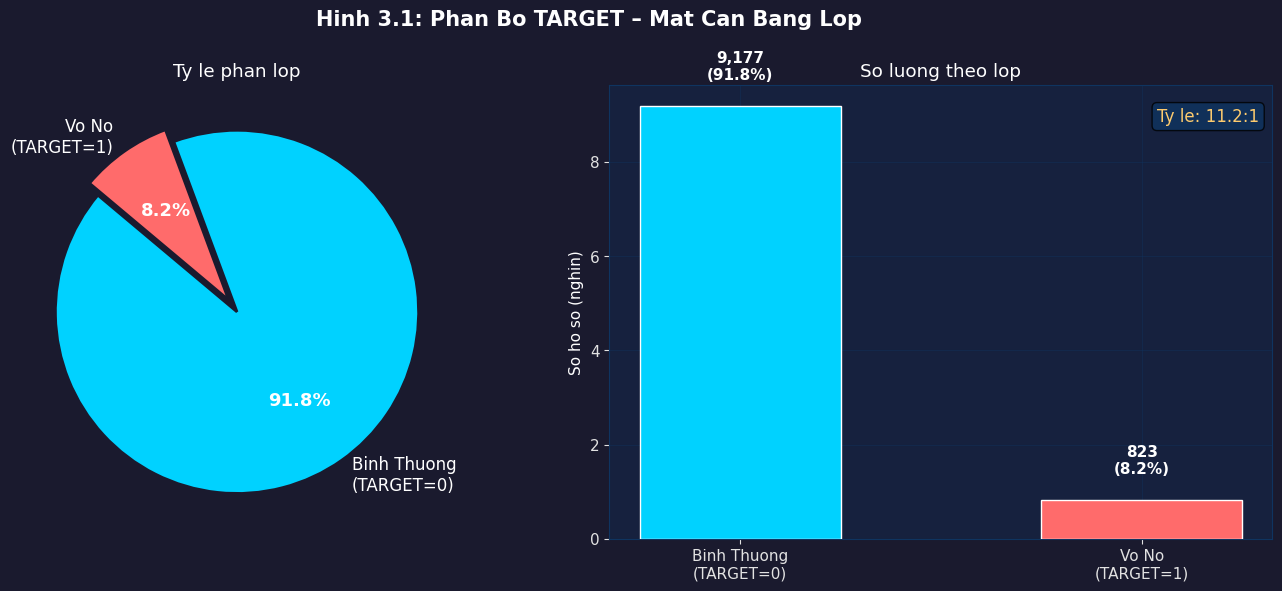

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hinh 3.1: Phan Bo TARGET – Mat Can Bang Lop',
              fontsize=15, fontweight='bold', color='white')
labels = ['Binh Thuong\n(TARGET=0)', 'Vo No\n(TARGET=1)']
colors = [PALETTE['normal'], PALETTE['default']]
wedges, texts, autotexts = ax1.pie(
    tc.values, labels=labels, colors=colors, explode=(0, 0.08),
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 12, 'color': 'white'},
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
ax1.set_title('Ty le phan lop', color='white')
ax1.set_facecolor('#16213e')
bars = ax2.bar(labels, tc.values/1000, color=colors,
               edgecolor='white', width=0.5, zorder=3)
for bar, val in zip(bars, tc.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')
ax2.set_ylabel('So ho so (nghin)', color='white')
ax2.set_title('So luong theo lop', color='white')
ax2.set_facecolor('#16213e')
ax2.text(0.98, 0.95, f'Ty le: {tc[0]/tc[1]:.1f}:1',
          transform=ax2.transAxes, ha='right', va='top', fontsize=12, color='#fdcb6e',
          bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.8))
plt.tight_layout()
savefig('fig_3_1_target_distribution.png')
plt.show()

## Hinh 3.3 – EXT_SOURCE theo TARGET

  [Plot] Saved: d:\credisdrick\figures\fig_3_3_ext_source.png


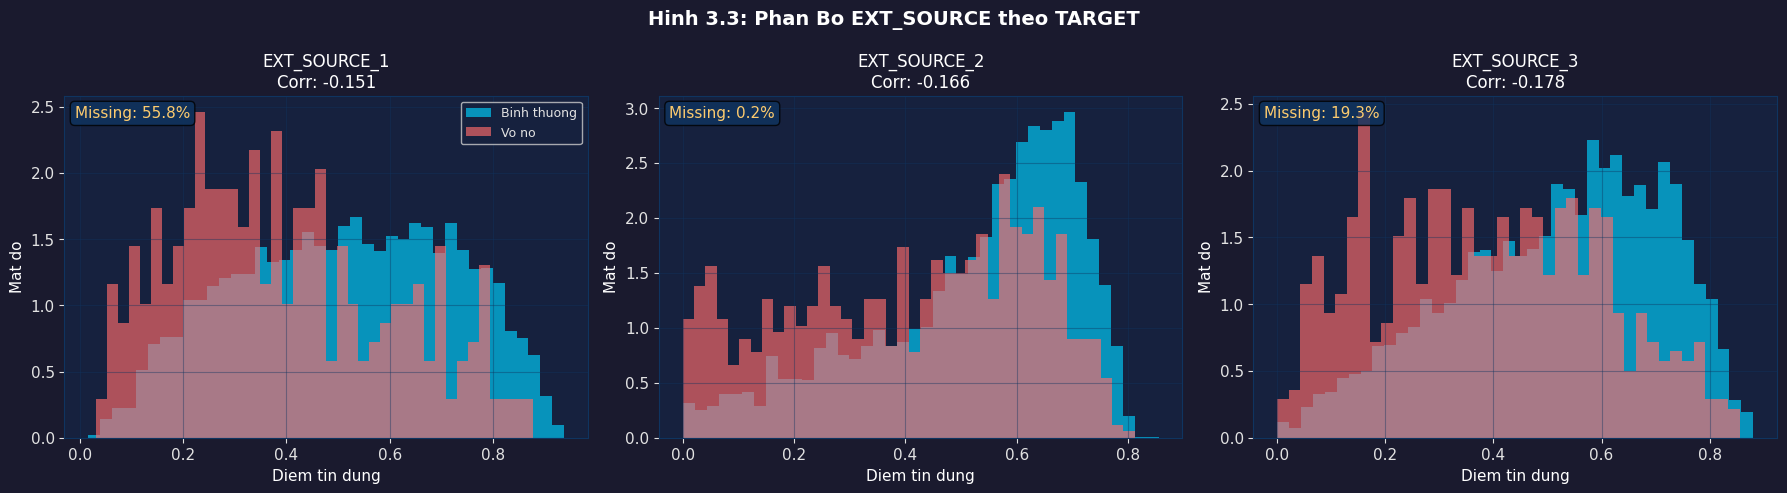

  EXT_SOURCE_1: corr=-0.151, missing=55.8%
  EXT_SOURCE_2: corr=-0.166, missing=0.2%
  EXT_SOURCE_3: corr=-0.178, missing=19.3%


In [3]:
ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in df.columns]
n = len(ext_cols)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1: axes = [axes]
fig.suptitle('Hinh 3.3: Phan Bo EXT_SOURCE theo TARGET',
              fontsize=14, fontweight='bold', color='white')
for i, col in enumerate(ext_cols):
    ax = axes[i]
    data = df[[col,'TARGET']].dropna()
    corr = data[col].corr(data['TARGET'])
    for t_val, color, label in [(0,PALETTE['normal'],'Binh thuong'),(1,PALETTE['default'],'Vo no')]:
        ax.hist(data[data['TARGET']==t_val][col], bins=40, alpha=0.65,
                color=color, label=label, edgecolor='none', density=True)
    ax.set_title(f'{col}\nCorr: {corr:.3f}', color='white', fontsize=12)
    ax.set_xlabel('Diem tin dung', color='white')
    ax.set_ylabel('Mat do', color='white')
    ax.set_facecolor('#16213e')
    miss = df[col].isna().mean()*100
    ax.text(0.02, 0.97, f'Missing: {miss:.1f}%', transform=ax.transAxes, va='top',
             color='#fdcb6e', bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.8))
    if i == 0: ax.legend(fontsize=9)
plt.tight_layout()
savefig('fig_3_3_ext_source.png')
plt.show()
for col in ext_cols:
    print(f'  {col}: corr={df[col].corr(df["TARGET"]):.3f}, missing={df[col].isna().mean()*100:.1f}%')

## Hinh 3.4 – Boxplot Bien Tai Chinh

  [Plot] Saved: d:\credisdrick\figures\fig_3_4_boxplot.png


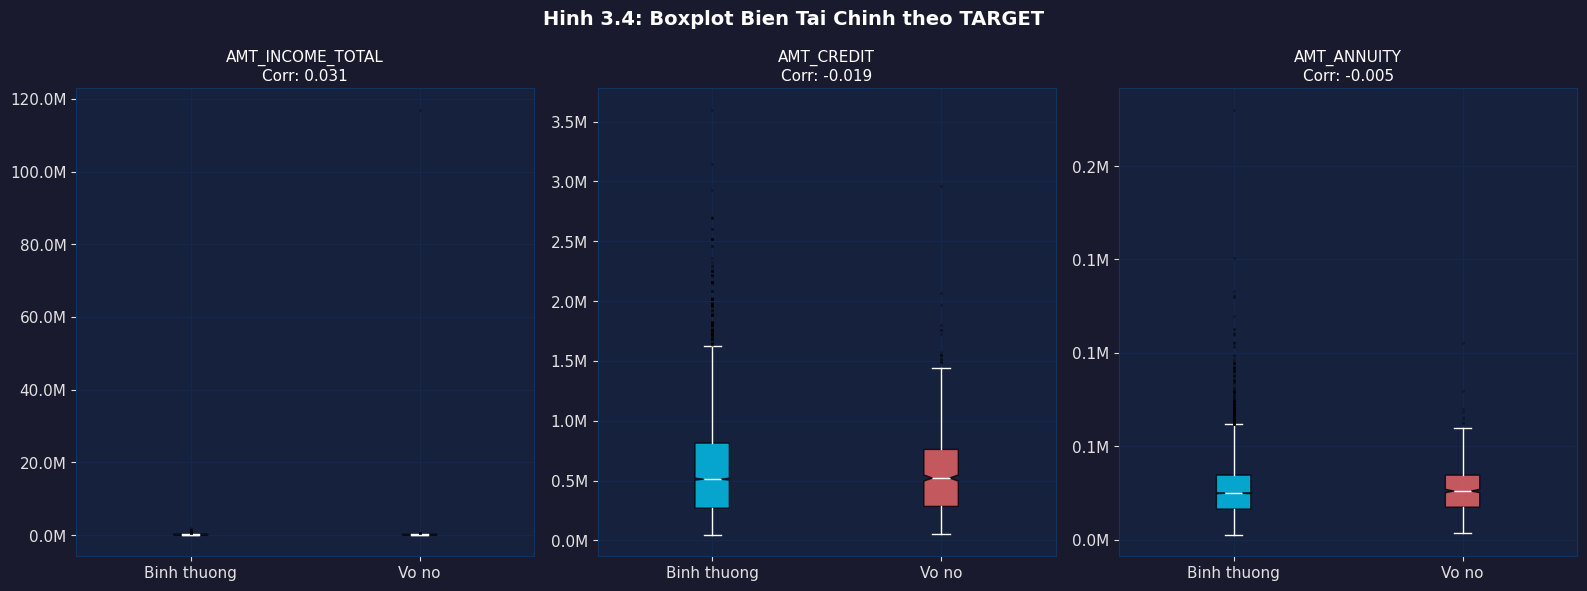

In [4]:
fin_cols = [c for c in ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY'] if c in df.columns]
fig, axes = plt.subplots(1, len(fin_cols), figsize=(16, 6))
if len(fin_cols)==1: axes=[axes]
fig.suptitle('Hinh 3.4: Boxplot Bien Tai Chinh theo TARGET',
              fontsize=14, fontweight='bold', color='white')
for i, col in enumerate(fin_cols):
    ax = axes[i]
    dp = [df[df['TARGET']==t][col].dropna().values for t in [0,1]]
    bp = ax.boxplot(dp, patch_artist=True, notch=True,
                     showfliers=True, flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for j,(box,c_) in enumerate(zip(bp['boxes'],[PALETTE['normal'],PALETTE['default']])):
        box.set_facecolor(c_); box.set_alpha(0.75)
    for el in ['whiskers','caps','medians']:
        for item in bp[el]: item.set_color('white')
    corr = df[col].corr(df['TARGET'])
    ax.set_title(f'{col}\nCorr: {corr:.3f}', color='white', fontsize=11)
    ax.set_xticks([1,2]); ax.set_xticklabels(['Binh thuong','Vo no'])
    ax.set_facecolor('#16213e')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M'))
plt.tight_layout()
savefig('fig_3_4_boxplot.png')
plt.show()

## Hinh 3.5 – Ma Tran Tuong Quan

  [Plot] Saved: d:\credisdrick\figures\fig_3_5_correlation.png


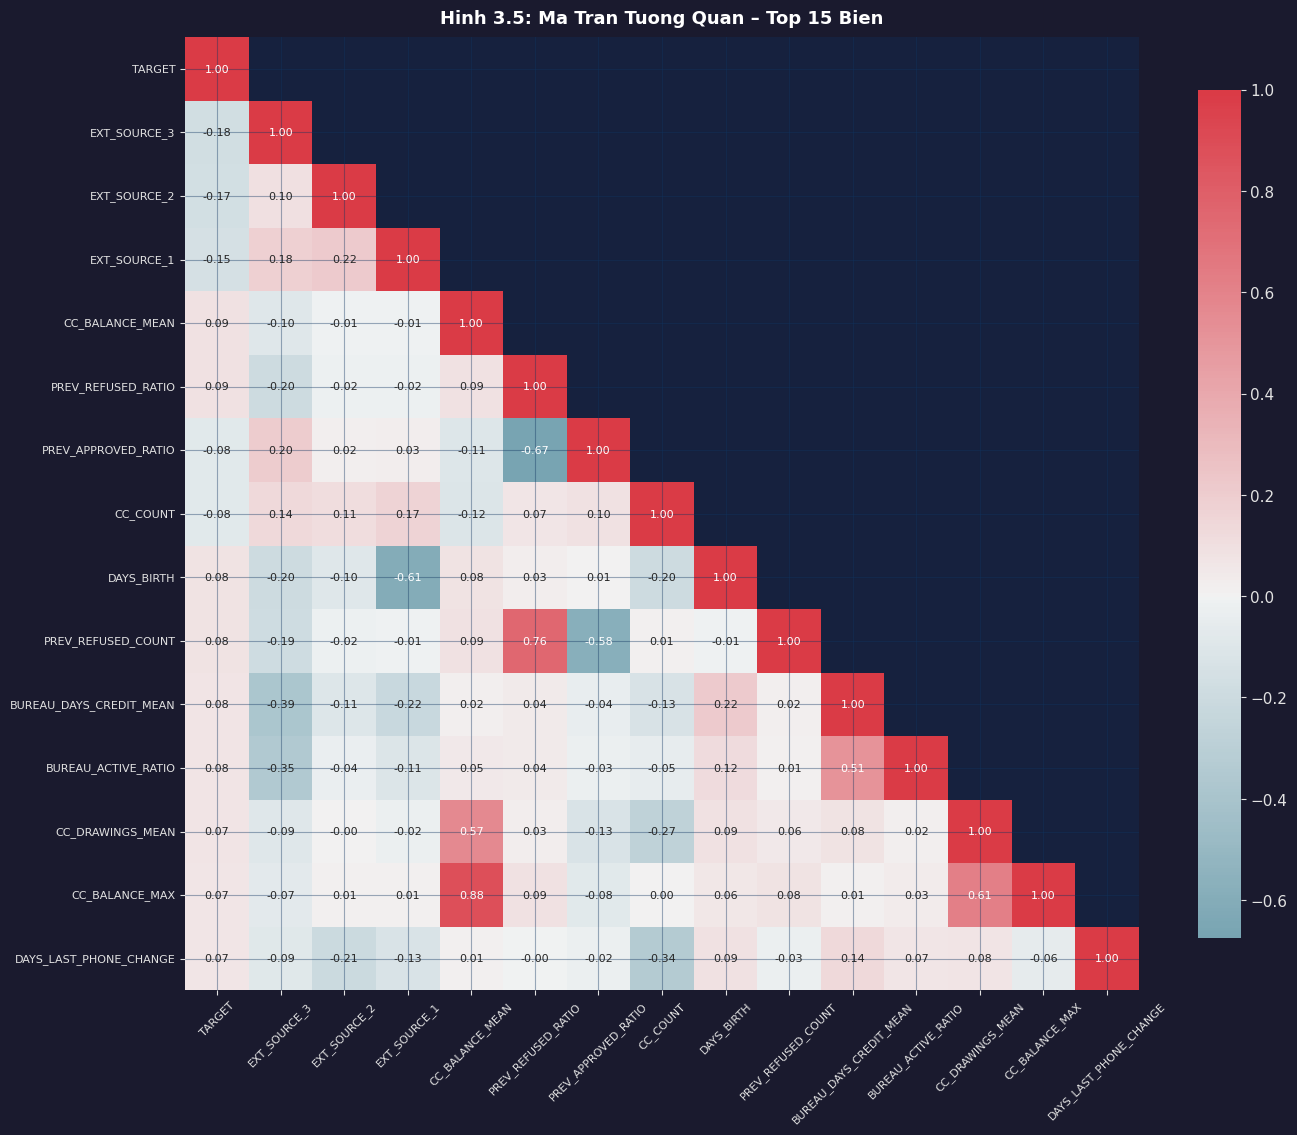

Top 5 tuong quan voi TARGET:
  TARGET: 1.000
  EXT_SOURCE_3: 0.178
  EXT_SOURCE_2: 0.166
  EXT_SOURCE_1: 0.151
  CC_BALANCE_MEAN: 0.092


In [5]:
num_c = [c for c in df.select_dtypes(include=[np.number]).columns
          if c not in ['SK_ID_CURR','TARGET']]
corr_t = df[num_c+['TARGET']].corr()['TARGET'].abs().sort_values(ascending=False)
top15 = corr_t.head(15).index.tolist()
corr_mat = df[top15].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
             cmap=sns.diverging_palette(220, 10, as_cmap=True),
             center=0, square=True, ax=ax,
             cbar_kws={'shrink':0.8}, annot_kws={'size':8})
ax.set_title('Hinh 3.5: Ma Tran Tuong Quan – Top 15 Bien',
              fontsize=13, fontweight='bold', color='white', pad=10)
ax.set_facecolor('#16213e')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
savefig('fig_3_5_correlation.png')
plt.show()
print('Top 5 tuong quan voi TARGET:')
for feat, c in corr_t.head(5).items():
    print(f'  {feat}: {c:.3f}')

## Hinh 3.6 – Top 20 Missing Values

  [Plot] Saved: d:\credisdrick\figures\fig_3_6_missing_values.png


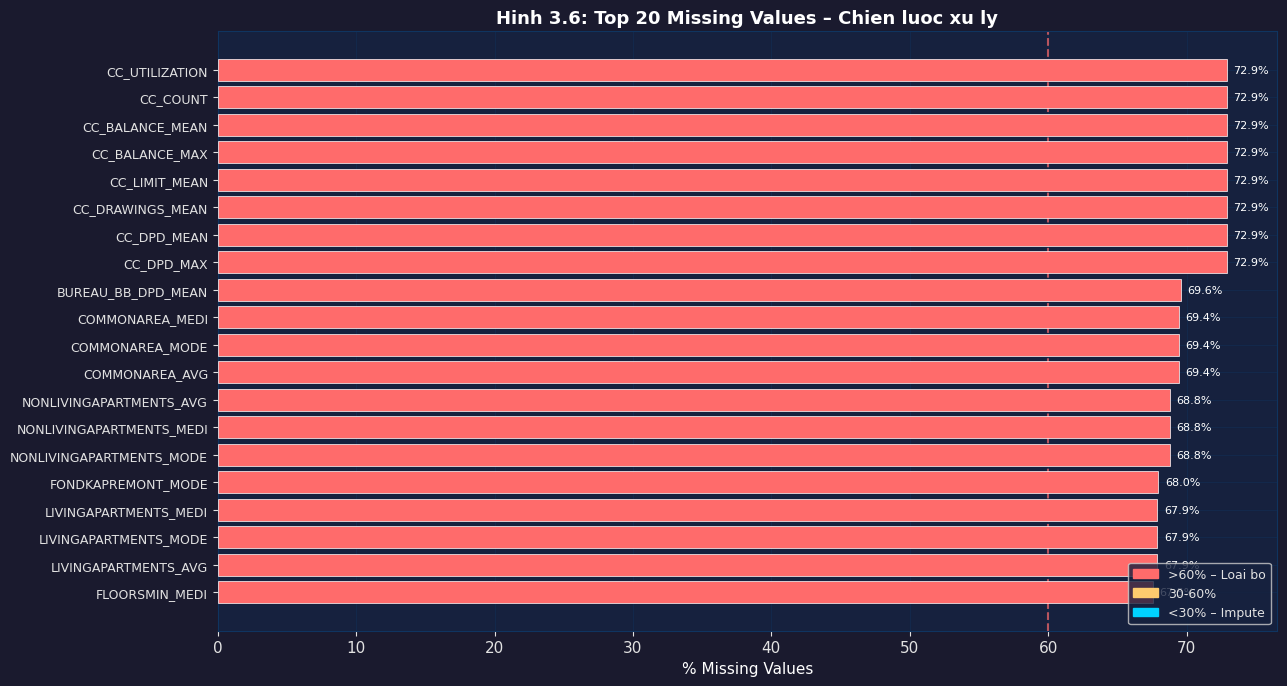

Cot missing > 60%: 20 -> se bi loai bo


In [6]:
miss_pct = (df.isnull().sum()/len(df)*100)
miss_pct = miss_pct[miss_pct>0].sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(13, 7))
bar_colors = ['#ff6b6b' if x>60 else '#fdcb6e' if x>30 else '#00d2ff'
               for x in miss_pct.values]
bars = ax.barh(range(len(miss_pct)), miss_pct.values,
               color=bar_colors, edgecolor='white', linewidth=0.5, zorder=3)
ax.set_yticks(range(len(miss_pct)))
ax.set_yticklabels(miss_pct.index, fontsize=9)
ax.axvline(60, color='#ff6b6b', linestyle='--', alpha=0.7)
for bar, val in zip(bars, miss_pct.values):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color='white')
ax.set_xlabel('% Missing Values', color='white')
ax.set_title('Hinh 3.6: Top 20 Missing Values – Chien luoc xu ly',
              fontsize=13, fontweight='bold', color='white')
ax.legend(handles=[Patch(color='#ff6b6b',label='>60% – Loai bo'),
                    Patch(color='#fdcb6e',label='30-60%'),
                    Patch(color='#00d2ff',label='<30% – Impute')],
           loc='lower right', fontsize=9)
ax.set_facecolor('#16213e'); ax.invert_yaxis()
plt.tight_layout()
savefig('fig_3_6_missing_values.png')
plt.show()
print(f'Cot missing > 60%: {(miss_pct>60).sum()} -> se bi loai bo')

## Tong Ket EDA

In [7]:
print('=== TONG KET EDA ===')
print(f'So ho so      : {len(df):,}')
print(f'So features   : {df.shape[1]}')
print(f'Imbalance     : {tc[0]/tc[1]:.1f}:1 (can xu ly)')
print()
print('Insight chinh:')
print('  1. Mat can bang (8.1%) -> Focal Loss + class weight')
print('  2. EXT_SOURCE la group features quan trong nhat')
print('  3. Nhieu cot missing > 60% -> loai bo')
print()
print('=== Notebook 02 HOAN THANH ===')
print('Chay tiep: 03_FeatureEngineering.ipynb')

=== TONG KET EDA ===
So ho so      : 10,000
So features   : 169
Imbalance     : 11.2:1 (can xu ly)

Insight chinh:
  1. Mat can bang (8.1%) -> Focal Loss + class weight
  2. EXT_SOURCE la group features quan trong nhat
  3. Nhieu cot missing > 60% -> loai bo

=== Notebook 02 HOAN THANH ===
Chay tiep: 03_FeatureEngineering.ipynb
